<a href="https://colab.research.google.com/github/luciestrada/Ejercicios-info2/blob/main/practica5_biose%C3%B1ales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRÁCTICA 5:  Introducción al análisis frecuencial de señales**

# **RESUMEN**

En esta práctica se usa Python para observar cómo se comportan las señales cuando se transforman al dominio de la frecuencia. Primero se hizo un estudio con unas ondas senoidales para identifcar frecuencias fundamentales de muestro, la potencia y la energía. Continuando, se usa la Transformada de Fourier para identificar las frecuencias de las señales.

Por otra parte, se analizaron los registros reales de ECG y EEG. En este caso se emplea método de Welch con ventanas Hanning; básicamente se segmenta la señal en cajones, se promedian y se limpia el ruido para poder comparar de manera correcta a los pacientes e identificar qué bandas de frecuencia presentan alteración. Al final, se filtran las señales anulando los componentes de ruido directamente en el espectro, y se utiliza la transformada inversa para obtener la señal nuevamente en el tiempo, comprobando con las gráficas la eliminación del ruido , y la conservación de la información importante de la señal.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch as pwelch
from scipy.io import loadmat

**1. Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40,
80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal,
y utilice la frecuencia de muestreo necesaria para representarla apropiadamente**

Frecuencia máxima de la señal: 160 Hz
Frecuencia de muestreo mínima (Nyquist): 320 Hz
Frecuencia de muestreo usada: 1000 Hz


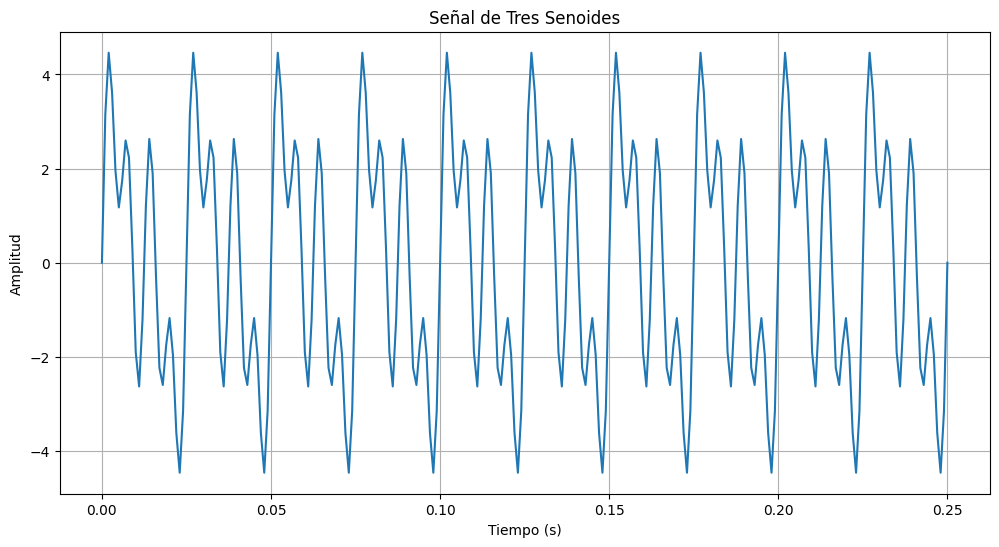

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# frecuencias
f1 = 40  # Hz
f2 = 80  # Hz
f3 = 160 # Hz


# frecuencia maxima --> teorema de nyquist
f_max = max(f1, f2, f3)

# Siguiendo lo del teorema de nyquist  ws > 2wmax
Fs_nyquist = 2 * f_max
print(f"Frecuencia máxima de la señal: {f_max} Hz")
print(f"Frecuencia de muestreo mínima (Nyquist): {Fs_nyquist} Hz")
print(f"Frecuencia de muestreo usada: {Fs} Hz")



# Usaremos la freucncia fudnamental de 1000
Fs = 1000 # Tiene que ser mayor de 320 Hz
T= 1/Fs

# El periodo fundamental es 1/40
Fo  = f1
Tp  = 1/Fo
t = np.arange(0, 10*Tp + T, T) # 10 periodos de la señal

A=2

# señales sinosoidales
x1 = A * np.sin(2 * np.pi * f1 * t)
x2 = A * np.sin(2 * np.pi * f2 * t)
x3 = A * np.sin(2 * np.pi * f3 * t)

# Sumamos
x = x1 + x2 + x3



plt.figure(figsize=(12, 6))
plt.plot(t, x)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal de Tres Senoides')
plt.grid(True)
plt.show()


El límite teórico es 320 Hz, pero en se usó 100 hZ, ya que una frecuencia de muestreo alta permite una reconstrucción visual mucho más detallada.

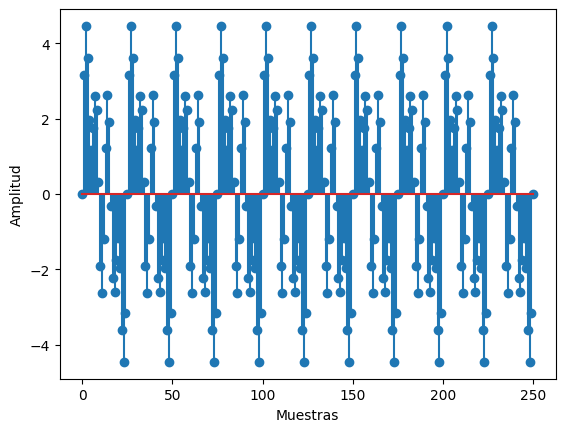

Número de muestras: 251


In [ ]:
n= np.arange(0,len(t))

plt.stem(n, x, 'o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

print(f"Número de muestras: {len(t)}")


**2. Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia.
Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos
de la señal).**

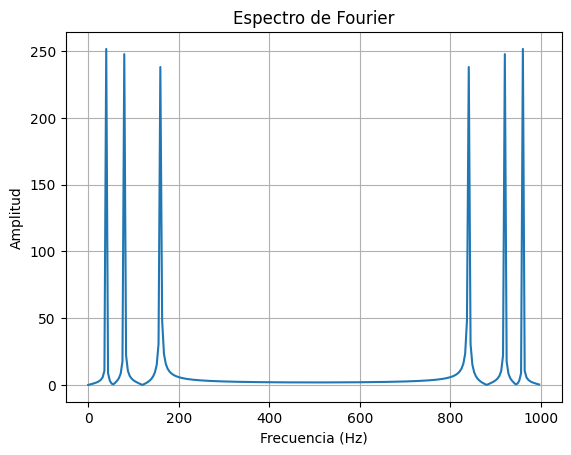

Frecuencias identificadas en el espectro:
  35.9 Hz  — amplitud: 10.63
  39.8 Hz  — amplitud: 251.62
  75.7 Hz  — amplitud: 17.52
  79.7 Hz  — amplitud: 247.72
  83.7 Hz  — amplitud: 22.02
  87.6 Hz  — amplitud: 10.55
  151.4 Hz  — amplitud: 15.16
  155.4 Hz  — amplitud: 30.61
  159.4 Hz  — amplitud: 238.06
  163.3 Hz  — amplitud: 48.25
  167.3 Hz  — amplitud: 23.28
  171.3 Hz  — amplitud: 15.86
  175.3 Hz  — amplitud: 12.27
  179.3 Hz  — amplitud: 10.15
  820.7 Hz  — amplitud: 10.15
  824.7 Hz  — amplitud: 12.27
  828.7 Hz  — amplitud: 15.86
  832.7 Hz  — amplitud: 23.28
  836.7 Hz  — amplitud: 48.25
  840.6 Hz  — amplitud: 238.06
  844.6 Hz  — amplitud: 30.61
  848.6 Hz  — amplitud: 15.16
  912.4 Hz  — amplitud: 10.55
  916.3 Hz  — amplitud: 22.02
  920.3 Hz  — amplitud: 247.72
  924.3 Hz  — amplitud: 17.52
  960.2 Hz  — amplitud: 251.62
  964.1 Hz  — amplitud: 10.63


In [ ]:
X = np.fft.fft(x)
N = len(X)

F = np.arange(0,N)*Fs/N

plt.plot(F,np.abs(X))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.title('Espectro de Fourier')
plt.grid(True)
plt.show()

# Identificar picos
picos_idx = np.where(np.abs(X) > 10)[0]
print("Frecuencias identificadas en el espectro:")
for idx in picos_idx:
    print(f"  {F[idx]:.1f} Hz  — amplitud: {np.abs(X[idx]):.2f}")

Se logran identificar los picos ( los valores con mayor amplitud)en:
* 39.8Hz ~40Hz
* 79.7Hz ~80Hz     
* 159.4Hz ~160Hz

Esto demuestra que la FFT ha identificado correctamente los tres componentes principales de la señal.

Hay otros valores con una amplitud alta:

* 840.6Hz  --> 1000 - 159.4Hz ~160Hz = 840.6 Hz
* 920.3Hz ~80Hz     
* 960 Hz ~40Hz

Esto se debe a que el espectro de la FFT de una señal real es **simétrico**.

  El punto de simetría es la mitad de tu Frecuencia de Muestreo ($F_s / 2$), conocida como la Frecuencia de Nyquist. --> Se logra deducir que la la frecuencia de muestreo es de 1000Hz( como se definió anteriormente), y que la frecuencia de Nyquist es de 500Hz.


**3. Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier.
Aplíquelo a la señal anterior.**

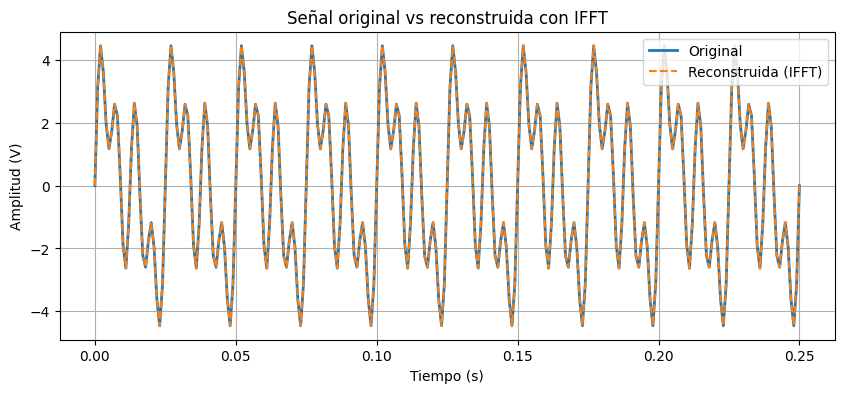

Error máximo de reconstrucción: 3.55e-15 


In [ ]:
# np.fft.ifft() calcula la transformada inversa discreta de Fourier

x_reconstruida = np.fft.ifft(X)

# Comparamos la señal original con la reconstruida
plt.figure(figsize=(10, 4))
plt.plot(t, x, label='Original', linewidth=2)
plt.plot(t, np.real(x_reconstruida), '--', label='Reconstruida (IFFT)', linewidth=1.5)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.title('Señal original vs reconstruida con IFFT')
plt.legend()
plt.grid(True)
plt.show()

# Error máximo entre anterior y nueva
error = np.max(np.abs(x - np.real(x_reconstruida)))
print(f"Error máximo de reconstrucción: {error:.2e} ")

Se observa que las dos gráficas se superponen , y el error es muy cercano a 0. Eso sucede porque la IFFT es un proceso reversible que permite recuperar la señal original intacta en el tiempo.

**4. ¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué?**

Extraiga de manera similar cada una de las componentes de la señal


```
F1 = np.fft.fft(x);
F2 = np.zeros((len(F1)));
F2[9:13] = F1[9:13];
xr = np.fft.ifft(F2);
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');
plt.show()

```



1. Toma la FFT de x,y pone a cero todos los coeficientes.

2. Copia únicamente los valores de la FFT  que están entre las posiciones-índices entre 9 y 12. Y los añade en el arreglo de ceros.


Al hacer cero todas las demás componentes frecuenciales y dejar solo un pequeño rango, solo se deja pasar ciertas frecuencias. Esto se puede interpretar como un filtro pasa banda ya que, solo deja pasar las frecuencias correspondientes a esos índices. **SI ES UN FILTRO**



In [ ]:
# A qué frecuencias corresponden los índices del 9 al 12
for k in range(9, 13):
    print(f"Índice k={k} → {k * Fs / N:.1f} Hz")
    #F = k * Fs / N  (con N = len(x), Fs = 1000)

Índice k=9 → 35.9 Hz
Índice k=10 → 39.8 Hz
Índice k=11 → 43.8 Hz
Índice k=12 → 47.8 Hz


Se usa un rango de índices del 9 al 12, porque la idea es capturar no solo la frecuencia central sino también las componentes adyacentes producto de la fuga espectral (una parte de su energía "se derrama" hacia los cajones vecinos) Al elegir un rango se garantiza que la energía total de la componente de 40 Hz sea recuperada al aplicar la transformada inversa."

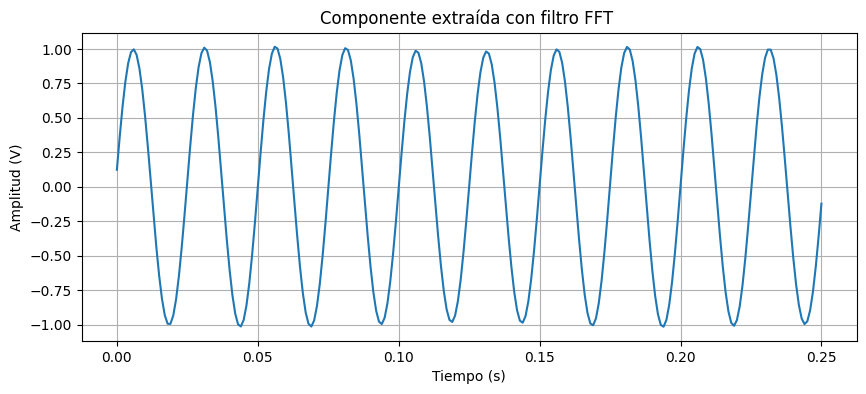

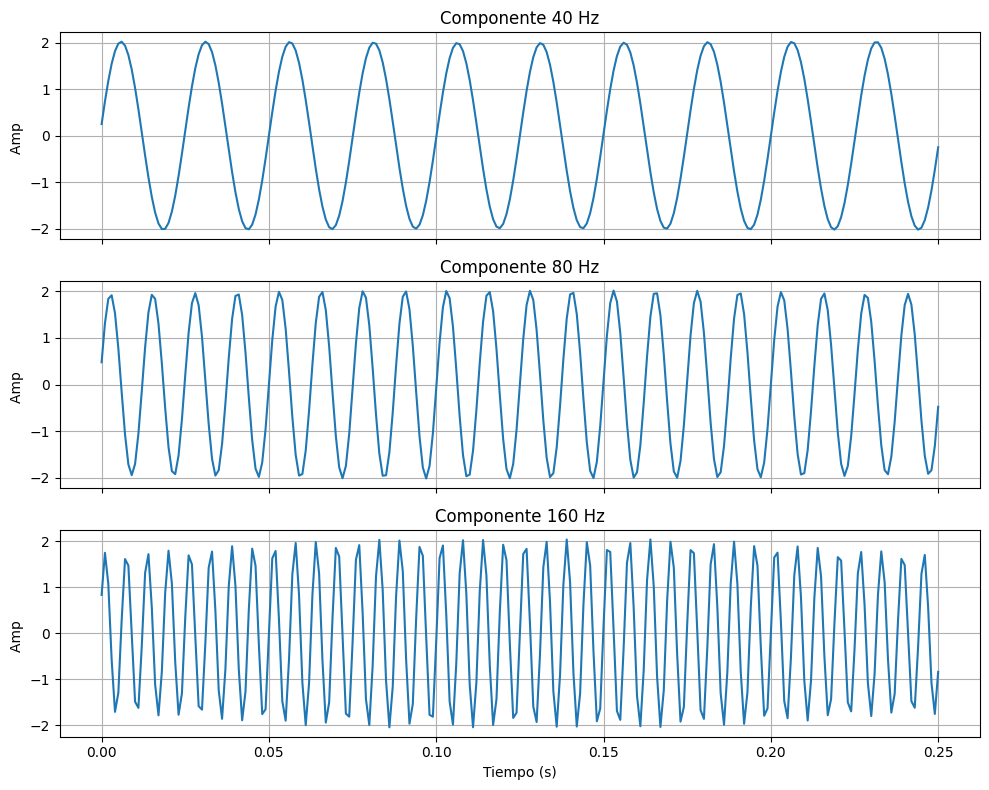

In [36]:
F1_fft = np.fft.fft(x)
F2_fft = np.zeros(len(F1_fft), dtype=complex)
F2_fft[9:13] = F1_fft[9:13]
xr = np.fft.ifft(F2_fft)

plt.figure(figsize=(10, 4))
plt.plot(t, np.real(xr))
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud (V)')
plt.title('Componente extraída con filtro FFT ') # Indices 9-12 → 40 Hz)
plt.grid(True)
plt.show()

# Extracción de cada una de las componentes de la señal

def extraer_componente(x, Fs, Fo_objetivo, tolerancia=5):
    #Extrae una componente frecuencial zeroing el resto del espectro
    N   = len(x)
    X   = np.fft.fft(x)
    F   = np.arange(N) * Fs / N
    X_f = np.zeros(N, dtype=complex)

    # Se buscan los indices de la frecuencia de interes y su espejo. y lo demás queda en 0
    for k in range(N):
        if abs(F[k] - Fo_objetivo) < tolerancia or abs(F[k] - (Fs - Fo_objetivo)) < tolerancia:
          #Se rescata tanto el pico original como su imagen espejo, el código original solo tomaba la parte positiva
            X_f[k] = X[k]
    return np.real(np.fft.ifft(X_f))

comp_40  = extraer_componente(x, Fs, 40)
comp_80  = extraer_componente(x, Fs, 80)
comp_160 = extraer_componente(x, Fs, 160)

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axes[0].plot(t, comp_40);  axes[0].set_title('Componente 40 Hz');  axes[0].set_ylabel('Amp ')
axes[1].plot(t, comp_80);  axes[1].set_title('Componente 80 Hz');  axes[1].set_ylabel('Amp ')
axes[2].plot(t, comp_160); axes[2].set_title('Componente 160 Hz'); axes[2].set_ylabel('Amp ')
axes[2].set_xlabel('Tiempo (s)')
for ax in axes: ax.grid(True)
plt.tight_layout()
plt.show()

Al observar la señal extraída con el filtro de los índices 9 a 12, se nota que la amplitud de la onda resultante es de 1 , a pesar de que la componente original tenía una amplitud de 2 . Esto ocurre porque el filtro implementado es unilateral; es decir, solo recupera la parte de las frecuencias positivas del espectro y no tiene en cuenta la parte simétrica de alta frecuencia.

Por otro lado, se observa que las 3 gráficas de los componentes mantienen la forma de onda senoidal pura, lo que confirma que el filtrado en el dominio frecuencial no distorsionó la señal en el dominio temporal.

---
**5. El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de
muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas
de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que
se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de
Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning,
y justificar la elección del solapamiento y el ancho de la ventaja**

In [ ]:
from google.colab import files
uploaded = files.upload()
data = loadmat('/content/senecg.mat')

Saving senecg.mat to senecg (1).mat


El contenido frecuencial útil del ECG se concentra entre **0.5 y 40 Hz**.

Por encima de 40–50 Hz lo que aparece en el espectro suele ser ruido de interferencia de la red eléctrica o ruido de alta frecuencia introducido por el equipo de adquisición o movimiento del paciente.

---
El método de Welch divide la señal en segmentos solapados,aplica una ventana a cada uno, calcula la FFT de cada segmento y promedia los espectros resultantes.

Esto reduce drásticamente la varianza, pero presenta una ligera reducción en la resolución frecuencial (al usar un $N$ menor por ventana), lo cual es aceptable cuando *se quiere identificar bandas de ruido, no frecuencias individuales exactas.*

Este método permite obtener un espectro suavizado donde se pueden identificar claramente las bandas de energía de interés.

---


* **Ventana de Hanning**: Su objetivo principal es suavizar los extremos de la señal, evitando cambios bruscos que puedan generar distorsión o fuga espectral. Este atenúa gradualmente los extremos de cada segmento hacia cero.

**Matematicamente** la ventana de Hanning multiplica cada segmento por una función coseno que vale cero en los extremos y uno en el centro.

*<<Para señales biológicas como el ECG, donde coexisten componentes de muy distinta amplitud, controlar la fuga espectral es fundamental para no ocultar componentes débiles bajo los extremos laterales de componentes fuertes.>>* (Harris ,1978).





---
* **ANCHO DE VENTANA:** 2 segundos es el equilibrio estándar recomendado para señales cardíacas de corta duración (Proakis & Manolakis, 2007).

La resolución es ( ancho):  $\Delta f = 1 / T$.

La elección de 2 segundos es el "punto óptimo" porque garantiza una resolución frecuencial exacta de 0.5 Hz. Esto es suficiente para separar espectralmente el ruido (50 Hz) de la señal fisiológica (< 40 Hz), es decir, se puede diferenciar más fácilmente el ruido de 50 Hz, aislado , y posteriormente realizar un filtrado sin afectar los datos principales del ECG. Al mismo tiempo que permite dividir la señal en suficientes segmentos temporales para que el promedio de Welch reduzca la varianza de manera efectiva.

con **Δf = 0.5 Hz**: Hay 20 "cajones" ( 10/0.5 = 20) entre 40 y 50 Hz, cantidad suficiente para visualizar de manera eficiente la separación de los componentes de la señal.

---

( *Con ventanas más cortas, no se puede disntiguir de manera precisa el pico del ruido*

*Con ventanas más largas se reduciría el número de segmentos disponibles para promediar y aumentaría la varianza del estimador*)



---
* **Solapamiento**: Como la ventana Hanning hace que los extremos de la señal valgan cero, se está borrando y perdiendo la información que estaba al principio, por lo que las muestras en los bordes del segmento contribuyen muy poco.

Por tal razón , es necesario realizar un solapamiento para recuperar la información que la ventana intentó borrar en los bordes.

En este caso se realiza con solapamiento del 50 %, para que cada muestra quede cerca del centro de al menos un segmento, donde la ventana tiene ganancia máxima. Sin solapamiento, la información en esas muestras se pierde.

*Con 50 % de solapamiento y ventana Hanning se obtiene la máxima reducción de varianza por unidad de costo computacional (Welch, 1967).*

Duración de la señal ECG: 5.00 s  (1250 muestras)


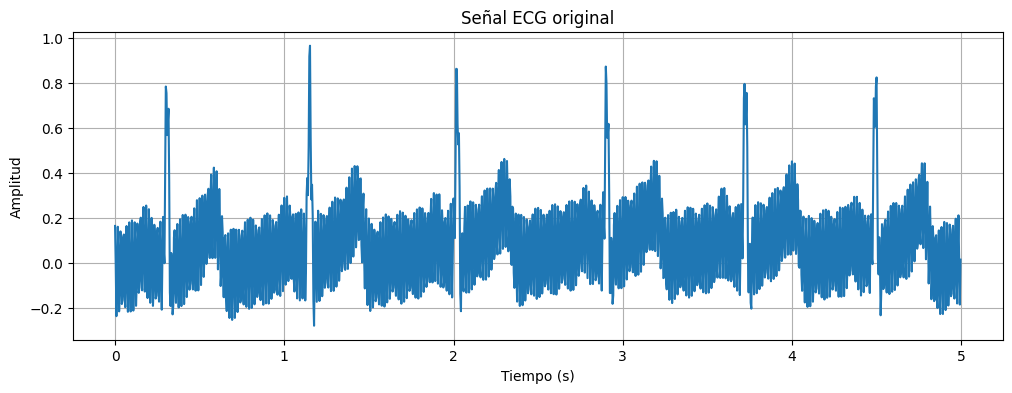

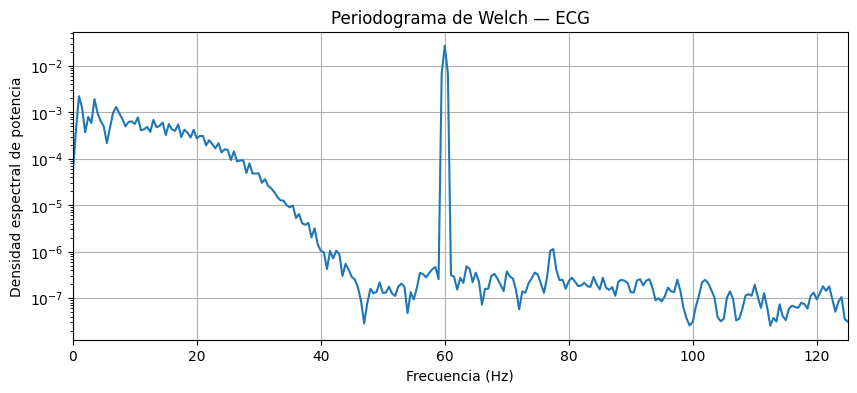

In [44]:

ecg  = data['ECG'].flatten()
Fs_ecg = 250                   # Hz
N_ecg  = len(ecg)
t_ecg  = np.arange(N_ecg) / Fs_ecg

print(f"Duración de la señal ECG: {N_ecg/Fs_ecg:.2f} s  ({N_ecg} muestras)")

# Señal en el tiempo
plt.figure(figsize=(12, 4))
plt.plot(t_ecg, ecg)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG original')
plt.grid(True)
plt.show()

#  Periodograma de Welch

# Ancho de ventana: 2 s → nperseg = 2 * Fs = 500 muestras.
#   → resolución frecuencial = Fs/nperseg = 250/500 = 0.5 Hz .
# Solapamiento: 50 % → noverlap = nperseg // 2


nperseg  = 2 * Fs_ecg          # 500 muestras = 2 s de ventana
noverlap = nperseg // 2        # 50 % de solapamiento

f_ecg, Pxx_ecg = pwelch(ecg, Fs_ecg, 'hann', nperseg, noverlap)

plt.figure(figsize=(10, 4))
plt.semilogy(f_ecg, Pxx_ecg)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad espectral de potencia')
plt.title('Periodograma de Welch — ECG')
plt.xlim(0, Fs_ecg/2)
plt.grid(True)
plt.show()




En la señal original se ve como un trazo más grueso, el cual representa  una oscilación constante y rápida montada sobre los latidos del corazón.

En el periodograma de Welch se observa que la señal contiene ruido relacionado a la red eléctrcia en 60 Hz y es necesario filtrar.

Es necesario aplicar un filtro paso-bajo , anulando todas las componentes superiores a 50 Hz

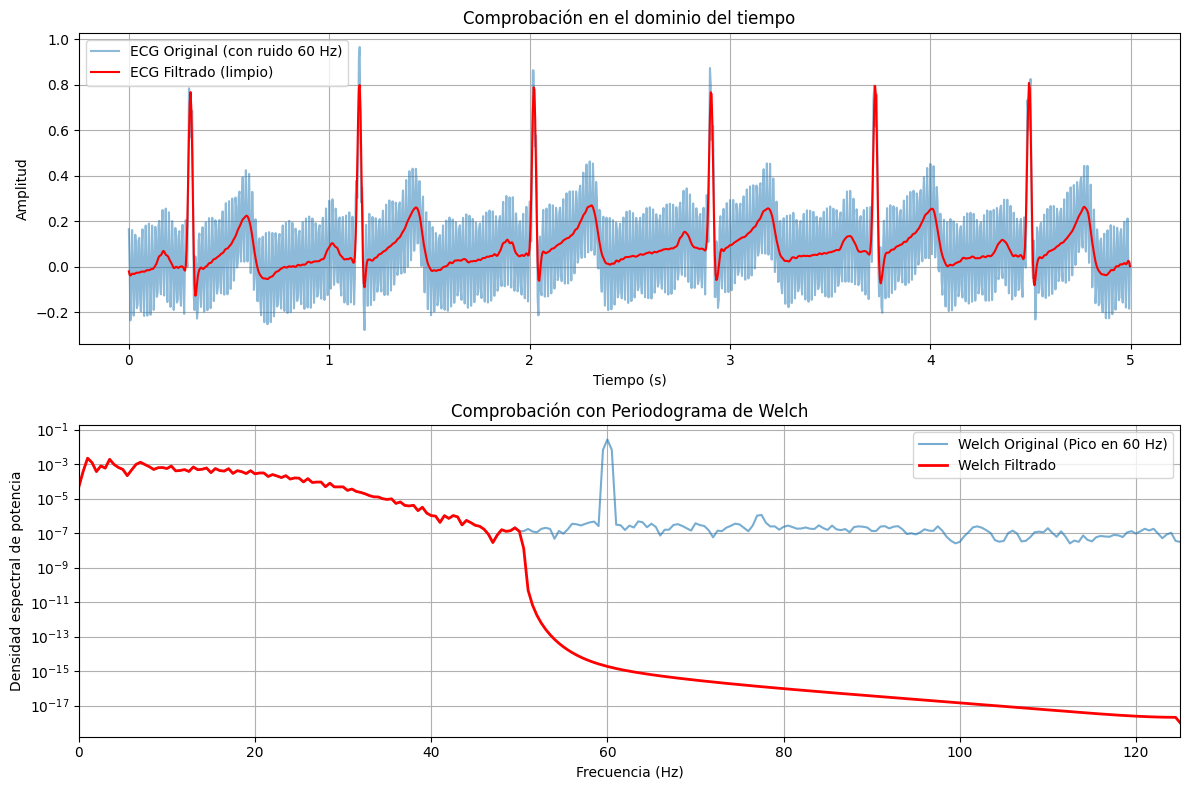

In [47]:
#Transformada de Fourier de la señal ECG completa
ECG_fft = np.fft.fft(ecg)
freqs = np.fft.fftfreq(N_ecg, d=1/Fs_ecg)

# Filtro paso-bajo ideal (Zeroing)

# La información vital del ECG está por debajo de los 50 Hz.
# Al poner en cero todo lo mayor a 50 Hz, eliminamos el ruido de 60 Hz y su espejo.

ECG_fft_filtrado = ECG_fft.copy()
ECG_fft_filtrado[np.abs(freqs) > 50] = 0

# Transformada Inversa (IFFT) para obtener el ECG limpio en el tiempo
ecg_limpio = np.real(np.fft.ifft(ECG_fft_filtrado))

# Calcular Welch de nuevo, pero a la señal limpia
f_limpio, Pxx_limpio = pwelch(ecg_limpio, Fs_ecg, 'hann', nperseg, noverlap)

# COMPARACIÓN
fig, axes = plt.subplots(2, 1, figsize=(12, 8))


axes[0].plot(t_ecg, ecg, label='ECG Original (con ruido 60 Hz)', alpha=0.5)
axes[0].plot(t_ecg, ecg_limpio, label='ECG Filtrado (limpio)', linewidth=1.5, color='red')
axes[0].set_xlabel('Tiempo (s)')
axes[0].set_ylabel('Amplitud')
axes[0].set_title('Comprobación en el dominio del tiempo')
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy(f_ecg, Pxx_ecg, label='Welch Original (Pico en 60 Hz)', alpha=0.6)
axes[1].semilogy(f_limpio, Pxx_limpio, label='Welch Filtrado', linewidth=2, color='red')
axes[1].set_xlabel('Frecuencia (Hz)')
axes[1].set_ylabel('Densidad espectral de potencia')
axes[1].set_title('Comprobación con Periodograma de Welch')
axes[1].set_xlim(0, Fs_ecg/2) # Solo se muestra hasta Nyquist
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Al realizar el filtrado la señal en el dominio del tiempo se ve mucho más fina, y limpia si deformar la estructura fisiológica del latido cardíaco.

Al observar el perdiodograma de Welch de la señal filtrada, se visualiza que se sobrepone perfectamente la energía de la señal original en las frecuencias bajas (de 0 a 50 Hz), lo que demuestra que la información  quedó intacta. Sin embargo, justo después de los 50 Hz, la curva cae bruscamente. y el pico de 60 Hz ha desaparecido.

---

**6. Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG
de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto
1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al
azar. Realice un análisis comparativo de las señales según lo que le indiquen los
periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el
ancho de la ventaja)**

En el proyecto anterior no se encontró ningún canal significativo. Sin embargo el canal O2 mostró las mayores diferencias entre grupos en las bandas Theta y Alpha, lo que lo convierte en el canal más discriminante y el seleccionado para este estudio.

**Se elige el par C002–P025, canal O2**


La enfermedad de Parkinson es un trastorno neurodegenerativo que afecta
principalmente los circuitos motores y cognitivos. En el EEG, los pacientes
con Parkinson en reposo presentan alteraciones espectrales documentadas:


- **Enlentecimiento del espectro**: aumento de potencia en bandas lentas
  (Delta y Theta).

- **Alteración del ritmo alfa occipital**: La banda alfa (8–13 Hz) disminuye o se desplaza en la zona occipital, reflejando fallos tálamo-corticales.

- **Reducción de beta en regiones motoras**: la banda beta en electrodos
  centrales (C3, CZ, C4) se reduce por la rigidez y lentitud de movimiento.

  ---

**Elección de parámetros de Welch**

* **Ventana de Hanning:** Misma justificación que en el ECG: reduce la fuga espectral.

   En EEG es particularmente importante porque las bandas funcionales (Alpha, Beta, Theta) son adyacentes y tienen amplitudes similares. *La fuga de una banda a otra contaminaría la estimación de potencia relativa entre ellas*

* **Ancho de ventana:** Con resolución de 0.5 Hz se distinguen perfectamente las bandas EEG

*  **Solapamiento: 50 %**:

 $N_s ≈ 2 × (duración_t / duración_v) - 1$

 Con señales EEG de reposo de 5–6 minutos y ventanas de 2 s, un solapamiento del 50 % . Produce ~300–400 segmentos para promediar

In [13]:
# ─── Carga de datos (misma estructura del proyecto 1) ────────────────────────
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import welch as pwelch

drive.mount('/content/drive')

ruta_control   = "/content/drive/MyDrive/datos_senales_datos_parkinson_cursos/control"
ruta_parkinson = "/content/drive/MyDrive/datos_senales_datos_parkinson_cursos/parkinson"

channels = ['C3', 'C1', 'CZ', 'C2', 'C4', 'O1', 'OZ', 'O2']
Fs = 1000

CH_IDX  = 7
CH_NAME = channels[CH_IDX]

def cargar_señal_canal(ruta, ch_idx):
# data shape = (8 canales, 2000 muestras, N épocas)

    señales = []
    sujetos = []
    for archivo in sorted(os.listdir(ruta)):
        if archivo.endswith('.mat'):
            data = loadmat(os.path.join(ruta, archivo))['data']
            # Concatenar épocas → reconstruir la señal continua del canal
            señal = data[ch_idx, :, :].flatten(order='F')
            señales.append(señal)
            sujetos.append(archivo.replace('.mat', ''))
    return señales, sujetos

señales_control,   sujetos_control   = cargar_señal_canal(ruta_control,   CH_IDX)
señales_parkinson, sujetos_parkinson = cargar_señal_canal(ruta_parkinson, CH_IDX)

print(f"Canal analizado: {CH_NAME}  (índice {CH_IDX})")
print(f"Sujetos control:   {sujetos_control}")
print(f"Sujetos Parkinson: {sujetos_parkinson}")

Mounted at /content/drive
Canal analizado: O2  (índice 7)
Sujetos control:   ['C004_EP_reposo', 'C005_EP_reposo_Repetido', 'C010_EP_reposo', 'C015_EP_reposo', 'C026_EP_reposo', 'C027_EP_reposo', 'C030_EP_reposo', 'C036_EP_reposo']
Sujetos Parkinson: ['P001_EP_reposo', 'P004_EP_reposo', 'P007_EP_reposo', 'P012_EP_reposo', 'P013_EP_reposo', 'P015_EP_reposo', 'P016_EP_reposo', 'P018_EP_reposo', 'P020_EP_reposo', 'P025_EP_reposo', 'P026_EP_reposo', 'P033_EP_reposo']


In [48]:
# Parámetros Welch
# Ventana: Hanning — reduce la fuga espectral; apropiada para EEG
#   porque suaviza los bordes de cada segmento evitando artefactos espectrales.

# Ancho de ventana: 2 s → nperseg = 2000 muestras
#   Resolución frecuencial = Fs / nperseg = 1000/2000 = 0.5 Hz
#   Permite distinguir claramente Delta, Theta, Alpha, Beta y Gamma.

# Solapamiento: 50 % → noverlap = nperseg // 2
#   Reduce la varianza del estimador sin introducir redundancia excesiva;

nperseg  = 2 * Fs        # 2000 muestras
noverlap = nperseg // 2  # 50 %

def calcular_welch_grupo(señales):
# Se calcula welch para cada sujeto
    resultados = []
    for sig in señales:
        f, P = pwelch(sig, Fs, 'hann', nperseg, noverlap)
        resultados.append((f, P))
    return resultados

welch_control   = calcular_welch_grupo(señales_control)
welch_parkinson = calcular_welch_grupo(señales_parkinson)

# Densidad Espectral de Potencia  promedio por grupo
f_eje   = welch_control[0][0]  # mismo eje de frecuencias para todos
P_ctrl  = np.mean([P for _, P in welch_control],   axis=0)
P_park  = np.mean([P for _, P in welch_parkinson], axis=0)

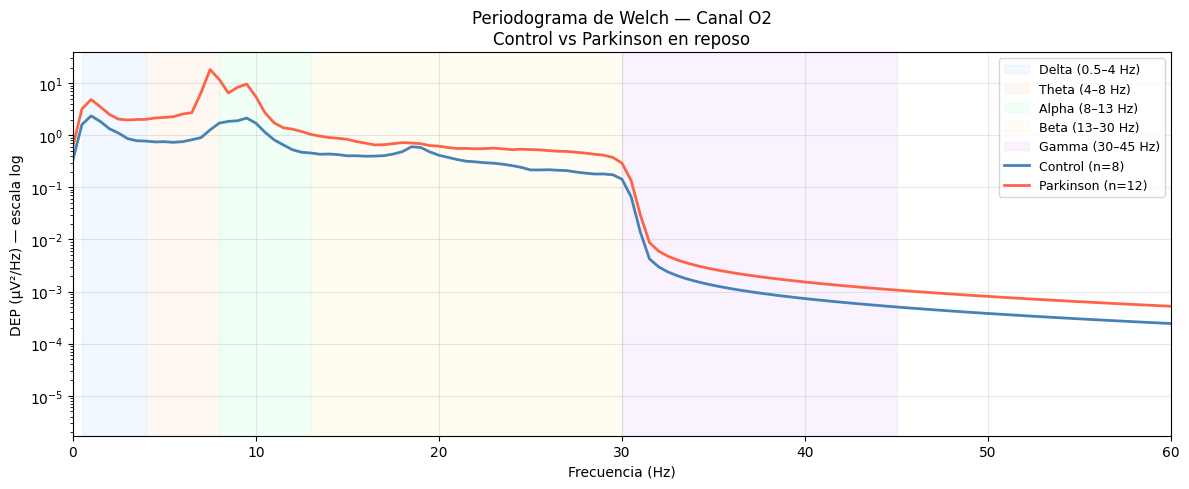

In [40]:
# Densidad Espectral de Potencia promedio por grupo


bandas = {
    'Delta\n(0.5–4 Hz)':  (0.5, 4), #Sueño profundo, estados patológicos
    'Theta\n(4–8 Hz)':    (4,   8), #Somnolencia, memoria, estados cognitivos
    'Alpha\n(8–13 Hz)':   (8,  13), #Reposo con ojos cerrados, relajación
    'Beta\n(13–30 Hz)':   (13, 30), #Actividad cognitiva, movimiento voluntario
    'Gamma\n(30–45 Hz)':  (30, 45), #Procesamiento sensorial de alto nivel
}
colores_banda = ['#cce5ff', '#ffe5cc', '#ccffdd', '#fff5cc', '#f0ccff']

fig, ax = plt.subplots(figsize=(12, 5))

for (banda, (fl, fh)), cb in zip(bandas.items(), colores_banda):
    ax.axvspan(fl, fh, alpha=0.25, color=cb, label=banda.replace('\n', ' '))

ax.semilogy(f_eje, P_ctrl, color='steelblue', linewidth=2,
            label=f'Control (n={len(señales_control)})')
ax.semilogy(f_eje, P_park, color='tomato',    linewidth=2,
            label=f'Parkinson (n={len(señales_parkinson)})')

ax.set_xlabel('Frecuencia (Hz)')
ax.set_ylabel('DEP (µV²/Hz) — escala log')
ax.set_title(f'Periodograma de Welch — Canal {CH_NAME}\nControl vs Parkinson en reposo')
ax.set_xlim(0, 60)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Los sujetos con Parkinson presentan una potencia considerablemente mayor en
las bandas Delta y Theta respecto a los S.controles. Esto se interpreta como un *enlentecimiento cortical* asociado a la degeneración.

- Los sujetos con Parkinson
muestran una potencia Alpha significativamente mayor en O2, lo cual es contradictorio a la teoría vista anteriormente. Sin embargo,esto se explica por 2 motivos:
   - El pico de eneríga se desplaza hacia frecuencias más bajas
   - Los pacientes pierden la capacidad normal de suprimir el ritmo alfa durante el procesamiento visual, lo que contribuye a ese aumento de potencia.

- En la banda Beta se observa un aumento inusual, probablemente ocurre porque el cerebro intenta compensar,o puede ser causado por medicamentos.



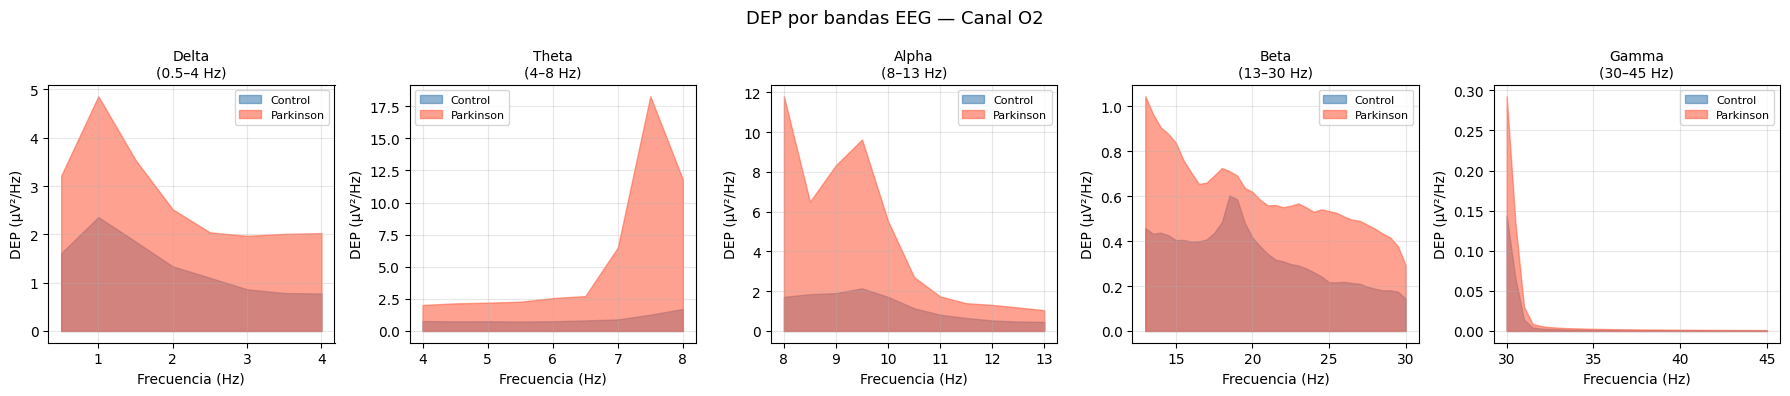

In [41]:
# Zoom por bandas
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, (banda, (fl, fh)), cb in zip(axes, bandas.items(), colores_banda):
    idx = np.where((f_eje >= fl) & (f_eje <= fh))[0]
    ax.fill_between(f_eje[idx], P_ctrl[idx], alpha=0.6,
                    color='steelblue', label='Control')
    ax.fill_between(f_eje[idx], P_park[idx], alpha=0.6,
                    color='tomato',    label='Parkinson')
    ax.set_title(banda, fontsize=10)
    ax.set_xlabel('Frecuencia (Hz)')
    ax.set_ylabel('DEP (µV²/Hz)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'DEP por bandas EEG — Canal {CH_NAME}', fontsize=13)
plt.tight_layout()
plt.show()

* **Banda delta:** Ambos grupos muestran la típica caída del EEG a frecuencias bajas. Aunque el Parkinson tiene una potencia absoluta 5.5 veces mayor. Esto significa que el aumento en Delta no es lo que caracteriza al Parkinson, sino que es un reflejo de que toda la señal de Parkinson tiene más amplitud en esta banda.

* **Banda theta**: En el sujeto sano, Theta es baja y plana . En cambio, el paciente con Parkinson muestra un pico muy grande en 7.5 Hz que concentra un gran porcentaje de la energía del EEG. El cual significa que casi todas las neuronas de esa zona se pusieron a oscilar al mismo tiempo a una marcha muy lenta. Este diferencia confirma el enlentecimiento cortical típico de esta enfermedad por la falta de dopamina.

* **Banda alpha**: En valores absolutos el Parkinson marca más potencia, pero en porcentaje cae a la mitad, porque por el gran incremento de Theta se "roba" casi todo el espectro. Adicionalmente se logra identificar, el desplazamiento del pico: el sano está en 10.5 Hz (frecuencia normal de reposo), mientras que el de Parkinson baja a 8.0 Hz. Esto es lo que se conoce como "alfa lento" y muestra que el cerebro está oscilando más despacio.

* **Banda beta**: En porcentaje, Beta disminuye en Parkinson debido al dominio de Theta. Aunque en los electrodos motores (C3, C4) lo normal es que Beta baje por la rigidez, en este caso se está midiendo la zona occipital, lo que explica por qué el patrón absoluto no disminuye.

* **Banda gamma**: En esta banda los valores son casi nulos para ambos grupos . Al estar en reposo, Gamma no aporta ningún dato relevante para el análisis.

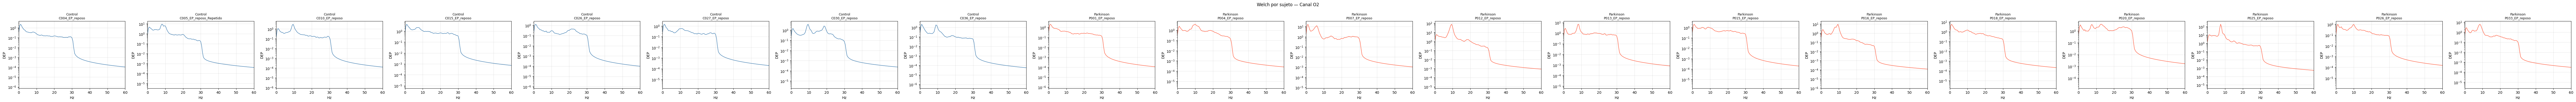

In [42]:
# Welch individual por sujeto
n_ctrl = len(welch_control)
n_park = len(welch_parkinson)
fig, axes = plt.subplots(1, n_ctrl + n_park,
                         figsize=(5*(n_ctrl + n_park), 4))

for i, (f, P) in enumerate(welch_control):
    axes[i].semilogy(f, P, color='steelblue', linewidth=1.2)
    axes[i].set_title(f'Control\n{sujetos_control[i]}', fontsize=9)
    axes[i].set_xlim(0, 60); axes[i].set_xlabel('Hz')
    axes[i].set_ylabel('DEP'); axes[i].grid(True, alpha=0.3)

for j, (f, P) in enumerate(welch_parkinson):
    axes[n_ctrl + j].semilogy(f, P, color='tomato', linewidth=1.2)
    axes[n_ctrl + j].set_title(f'Parkinson\n{sujetos_parkinson[j]}', fontsize=9)
    axes[n_ctrl + j].set_xlim(0, 60); axes[n_ctrl + j].set_xlabel('Hz')
    axes[n_ctrl + j].set_ylabel('DEP'); axes[n_ctrl + j].grid(True, alpha=0.3)

plt.suptitle(f'Welch por sujeto — Canal {CH_NAME}', fontsize=12)
plt.tight_layout()
plt.show()

In [43]:
# ─── Tabla de potencia media por banda ───────────────────────────────────────
print(f"\nCanal {CH_NAME} — Potencia media por banda (µV²/Hz)")
print(f"{'Banda':<22} {'Control':>14} {'Parkinson':>14} {'Ratio P/C':>12}")
print("─" * 65)

for banda, (fl, fh) in bandas.items():
    banda_txt = banda.replace('\n', ' ')
    idx = np.where((f_eje >= fl) & (f_eje <= fh))[0]
    pc  = np.mean(P_ctrl[idx])
    pp  = np.mean(P_park[idx])
    print(f"{banda_txt:<22} {pc:>14.4f} {pp:>14.4f} {pp/pc:>11.1f}x")


Canal O2 — Potencia media por banda (µV²/Hz)
Banda                         Control      Parkinson    Ratio P/C
─────────────────────────────────────────────────────────────────
Delta (0.5–4 Hz)               1.3351         2.7715         2.1x
Theta (4–8 Hz)                 0.9412         5.6121         6.0x
Alpha (8–13 Hz)                1.2183         4.6512         3.8x
Beta (13–30 Hz)                0.3322         0.6134         1.8x
Gamma (30–45 Hz)               0.0083         0.0170         2.0x


- Los resultados coinciden perfectamente con la teoría: el paciente con Parkinson sufre un enlentecimiento espectral donde la energía del cerebro se desplaza desde las frecuencias rápidas hacia las lentas, acumulándose casi por completo en la banda Theta.

# **CONCLUSIONES**

1. Al cambiar las señales al dominio de la frecuencia con la FFT y el método de Welch permite entender su composición y limpiarlas con precisión. Al aplicar la transformada inversa, se recupera la señal limpia en el tiempo, demostrando que filtrar en frecuencia es mucho más exacto y fácil de verificar que intentar corregir la onda directamente en el tiempo.

2.  Configurar el periodograma con una ventana Hanning de 2 segundos y un solapamiento del 50% funcionó a la perfección. La ventana Hanning evitó que las frecuencias se mezclaran (fuga espectral), los 2 segundos proporcionan la resolución necesaria (0.5 Hz) para separar bien las Bandas del EEG, y el solapamiento permitió evitar perder la información de los bordes. Esta combinación es el estándar técnico porque reduce el ruido visual del espectro sin perder datos clínicos.

3.  El análisis en el canal O2 identifica y confima que los pacientes con Parkinson sufren un enlentecimiento cortical donde la energía se desplaza a bandas lentas, especialmente a Theta. Sin embargo, a nivel grupal hay demasiada variabilidad; algunos pacientes tienen espectros parecidos a los sanos. Esto demuestra que para un diagnóstico robusto no basta con un solo canal en reposo; se necesitan más electrodos y controlar factores como la medicación.

# **ReferenciaS**

1. Harris, F. J. (1978). On the use of windows for harmonic analysis with
   the discrete Fourier transform. *Proceedings of the IEEE*, 66(1), 51–83.

2. Proakis, J. G., & Manolakis, D. G. (2007). *Digital Signal Processing:
   Principles, Algorithms, and Applications* (4th ed., pp. 75–77).
   Prentice Hall.

3. Welch, P. D. (1967). The use of fast Fourier transform for the estimation of power spectra: a method based on time averaging over short, modified periodograms.
